# Recurrent Neural Networks: Gradient Dynamics, Vanishing/Exploding Gradients, Leaky Units, LSTM, and GRU

This notebook addresses recurrent neural networks (RNNs), with special emphasis on:

1. the base RNN architecture,
2. unrolling in time and Backpropagation Through Time (BPTT),
3. the mathematical source of **vanishing** and **exploding** gradients,
4. rigorous norm-based proofs and spectral interpretation,
5. mitigation strategies such as clipping and orthogonal initialization,
6. memory-preserving designs: **leaky RNNs**, **LSTMs**, and **GRUs**,
7. annotated implementations in **PyTorch** and **JAX**.

---

## Learning outcomes

By the end of this notebook, you should be able to:

- derive the recurrence and output equations of a simple RNN,
- write BPTT as a product of Jacobians,
- explain why repeated Jacobian products can decay or blow up exponentially,
- prove basic gradient norm bounds,
- derive the gating equations of LSTM and GRU step by step,
- understand why additive memory paths reduce gradient decay,
- implement these models in PyTorch and JAX with mathematically annotated code.


## 1. Why sequence models require recurrence

In many learning problems, the input is not an unordered collection but a **sequence**:

- language modeling,
- speech recognition,
- machine translation,
- time-series forecasting,
- video and sensor processing,
- event streams and control systems.

A feedforward network processes each example independently. By contrast, a sequence model must maintain a **state** that summarizes the past.

The central idea of a recurrent model is therefore:

> At time $t$, the model combines the current input $x_t$ with a hidden summary of the past $h_{t-1}$ to produce a new hidden state $h_t$.

This turns the network into a discrete-time nonlinear dynamical system.


In [6]:
# Diagram: an RNN unrolled across time
# The same recurrent parameters are reused at every time step.

## 2. Simple RNN architecture

Let:

- $x_t \in \mathbb{R}^{d_x}$ be the input at time $t$,
- $h_t \in \mathbb{R}^{d_h}$ be the hidden state,
- $y_t \in \mathbb{R}^{d_y}$ be the output.

A standard simple RNN is:

$$
a_t = W_h h_{t-1} + W_x x_t + b_h
$$

$$
h_t = \phi(a_t)
$$

$$
o_t = W_y h_t + b_y
$$

$$
y_t = g(o_t)
$$

where:

- $W_h \in \mathbb{R}^{d_h \times d_h}$ is the recurrent weight matrix,
- $W_x \in \mathbb{R}^{d_h \times d_x}$ is the input-to-hidden matrix,
- $W_y \in \mathbb{R}^{d_y \times d_h}$ is the hidden-to-output matrix,
- $\phi$ is usually $\tanh$ or ReLU,
- $g$ depends on the task: identity, sigmoid, or softmax.

### Parameter sharing across time

A crucial point is that **the same matrices are reused at every time step**.  
This gives the model temporal consistency and keeps the number of parameters independent of the sequence length $T$.


## 3. Sequence loss and training objective

Suppose the model produces an output at every time step. A standard sequence loss is

$$
\mathcal{L} = \sum_{t=1}^{T} \ell_t(y_t, \hat y_t),
$$

where $\hat y_t$ is the target at time $t$.

Examples:

- mean squared error for regression,
- cross-entropy for token prediction or classification.

Even though the loss is written as a sum over time, the hidden states are **coupled recursively**, so the gradient at one time step depends on many earlier states.


## 4. Unrolling in time and Backpropagation Through Time (BPTT)

An RNN can be viewed as a deep network whose depth equals the sequence length.

After unrolling, each time step becomes one layer in a computation graph:

$$
h_0 \to h_1 \to h_2 \to \cdots \to h_T.
$$

The only difference from an ordinary deep network is that the same recurrent parameters are reused at each layer.

### Local Jacobian

Let

$$
a_t = W_h h_{t-1} + W_x x_t + b_h, \qquad h_t = \phi(a_t).
$$

Then the Jacobian of the hidden transition is

$$
\frac{\partial h_t}{\partial h_{t-1}}
=
D_t W_h,
$$

where

$$
D_t = \operatorname{diag}\big(\phi'(a_t)\big).
$$

This single matrix is the atomic object behind gradient flow in simple RNNs.


## 5. Gradient propagation through time

For $k < t$, repeated application of the chain rule gives

$$
\frac{\partial h_t}{\partial h_k}
=
\prod_{i=k+1}^{t} \frac{\partial h_i}{\partial h_{i-1}}
=
\prod_{i=k+1}^{t} D_i W_h.
$$

If the total loss depends on all time steps, then

$$
\frac{\partial \mathcal{L}}{\partial h_k}
=
\sum_{t=k}^{T}
\frac{\partial \mathcal{L}}{\partial h_t}
\frac{\partial h_t}{\partial h_k}.
$$

So every long-range gradient contains products of the form

$$
G_{k \to t} = \prod_{i=k+1}^{t} D_i W_h.
$$

This is the mathematical source of both instability modes:

- if $\|G_{k \to t}\|$ becomes tiny, gradients **vanish**,
- if $\|G_{k \to t}\|$ becomes huge, gradients **explode**.


## 6. Formal norm bound and the origin of vanishing/exploding gradients

Take any operator norm $\|\cdot\|$ that is submultiplicative. Then

$$
\left\|
\frac{\partial h_t}{\partial h_k}
\right\|
=
\left\|
\prod_{i=k+1}^{t} D_i W_h
\right\|
\le
\prod_{i=k+1}^{t} \|D_i\|\, \|W_h\|.
$$

If there exists a constant $\gamma < 1$ such that for all relevant times

$$
\|D_i\|\, \|W_h\| \le \gamma,
$$

then

$$
\left\|
\frac{\partial h_t}{\partial h_k}
\right\|
\le \gamma^{\,t-k},
$$

which decays **exponentially** with temporal distance $t-k$.

Likewise, if for long stretches the effective factor is typically larger than $1$, then the product can grow exponentially.

### Proof sketch

This follows immediately from repeated use of the submultiplicative property:

$$
\|AB\| \le \|A\|\,\|B\|.
$$

Hence

$$
\left\|
\prod_{i=k+1}^{t} D_i W_h
\right\|
\le
\prod_{i=k+1}^{t} \|D_i W_h\|
\le
\prod_{i=k+1}^{t} \|D_i\|\,\|W_h\|.
$$

If every factor is bounded above by $\gamma$, the full product is bounded above by $\gamma^{t-k}$.


In [7]:
# Diagram: repeated Jacobian products can decay or grow exponentially


## 7. Why saturating nonlinearities worsen vanishing gradients

For $\phi = \tanh$,

$$
\phi'(z) = 1 - \tanh^2(z),
$$

and therefore

$$
0 < \phi'(z) \le 1.
$$

When $|z|$ is large, $\tanh(z)$ saturates near $\pm 1$, so $\phi'(z)$ becomes close to $0$.

Thus the diagonal entries of $D_t$ can be very small, which shrinks the Jacobian product even when $W_h$ itself is reasonably scaled.

For sigmoid activations the issue is often worse because

$$
\sigma'(z) = \sigma(z)(1-\sigma(z)) \le \frac14.
$$

This means repeated multiplication of activation derivatives alone can generate severe exponential decay.


## 8. Spectral interpretation: eigenvalues, singular values, and long-range memory

A useful approximation is to imagine that the Jacobian does not change much across time:

$$
D_t W_h \approx J.
$$

Then

$$
\frac{\partial h_t}{\partial h_k} \approx J^{t-k}.
$$

If $J$ is diagonalizable,

$$
J = V \Lambda V^{-1},
$$

then

$$
J^n = V \Lambda^n V^{-1}.
$$

So the behavior is controlled by the eigenvalues of $J$:

- if all relevant modes satisfy $|\lambda_i| < 1$, then $J^n \to 0$,
- if some modes satisfy $|\lambda_i| > 1$, then those modes grow,
- if important modes stay near $1$, memory can persist.

In practice, for non-normal matrices the **singular values** and operator norms often give a more robust picture than eigenvalues alone, but the intuition is the same: repeated multiplication amplifies whatever lies above one and suppresses whatever lies below one.


## 9. Vanishing gradient: definition, consequences, and symptoms

We say the model suffers from **vanishing gradients** when gradients arriving from distant time steps become negligibly small:

$$
\left\|
\frac{\partial \mathcal{L}}{\partial h_k}
\right\|
\approx 0
\quad \text{for early } k.
$$

### Consequences

- the model fails to learn long-term dependencies,
- parameter updates are dominated by recent time steps,
- optimization becomes biased toward short-context solutions,
- training may look stable but plateaus early.

### Typical symptoms in practice

- the model predicts mostly from local context,
- training loss decreases only on short sequences,
- hidden states forget too quickly,
- learned dynamics resemble low-memory filters.


## 10. Exploding gradient: definition, consequences, and symptoms

We say the model suffers from **exploding gradients** when backpropagated signals become excessively large:

$$
\left\|
\frac{\partial \mathcal{L}}{\partial h_k}
\right\| \gg 1.
$$

### Consequences

- unstable parameter updates,
- loss spikes or NaNs,
- optimizer divergence,
- severe sensitivity to learning rate.

### A simple sufficient condition

If over some interval the effective Jacobian norm satisfies approximately

$$
\|D_i W_h\| \ge \beta > 1,
$$

then

$$
\left\|
\frac{\partial h_t}{\partial h_k}
\right\|
\gtrsim \beta^{\,t-k},
$$

which grows exponentially in temporal distance.


## 11. Gradient with respect to the recurrent matrix $W_h$

To see how temporal credit assignment enters parameter gradients, differentiate through the pre-activations:

$$
a_t = W_h h_{t-1} + W_x x_t + b_h.
$$

Then

$$
\frac{\partial \mathcal{L}}{\partial W_h}
=
\sum_{t=1}^{T}
\frac{\partial \mathcal{L}}{\partial a_t}
\frac{\partial a_t}{\partial W_h}.
$$

Since $a_t$ depends linearly on $W_h$,

$$
\frac{\partial \mathcal{L}}{\partial W_h}
=
\sum_{t=1}^{T}
\delta_t \, h_{t-1}^{\top},
\qquad
\delta_t := \frac{\partial \mathcal{L}}{\partial a_t}.
$$

But each $\delta_t$ itself depends on future losses through recurrence, so the long product of Jacobians still appears implicitly inside the parameter gradient.

That is why the optimization pathology is not just about hidden states; it directly affects learning of the recurrent weights.


## 12. Practical mitigation strategies for simple RNNs

### 12.1 Gradient clipping

The most common fix for exploding gradients is clipping:

$$
g \leftarrow g \cdot \min\left(1, \frac{\tau}{\|g\|}\right),
$$

where $g$ is the raw gradient vector and $\tau$ is a threshold.

This does **not** solve vanishing gradients, but it prevents catastrophic updates.

### 12.2 Orthogonal or identity-like initialization

If $W_h$ is initialized orthogonally, its singular values begin near $1$, which can slow both explosion and decay.

### 12.3 Careful activation choice

Using ReLU-like units can reduce saturation, but introduces other issues such as dead units or uncontrolled growth. No activation alone fully solves long-range memory.

### 12.4 Truncated BPTT

Instead of backpropagating through the entire sequence, one backpropagates through a shorter horizon. This improves computational cost and stability, but also limits the model's ability to learn long-range dependencies.


## 13. Leaky RNNs: adding a direct memory path

A classical idea is to let the old state leak into the new one directly:

$$
h_t = \alpha h_{t-1} + (1-\alpha)\tilde h_t,
$$

where

$$
\tilde h_t = \phi(W_h h_{t-1} + W_x x_t + b_h), \qquad 0 \le \alpha \le 1.
$$

Then the Jacobian contains a term approximately like

$$
\frac{\partial h_t}{\partial h_{t-1}}
\approx
\alpha I + (1-\alpha) D_t W_h.
$$

The identity contribution $\alpha I$ provides a **shortcut for gradient flow**.  
This is already much closer in spirit to modern residual and gated architectures.

However, the leakage coefficient is fixed or only weakly adaptive, so the model still lacks the fully learned memory control of LSTM/GRU.


## 14. LSTM: Long Short-Term Memory

LSTM was designed to preserve information over long time intervals using an explicit **cell state** $c_t$ and learned gates.

### 14.1 Standard LSTM equations

$$
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)
$$

$$
i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)
$$

$$
\tilde c_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)
$$

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t
$$

$$
o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)
$$

$$
h_t = o_t \odot \tanh(c_t)
$$

Interpretation:

- $f_t$: forget gate,
- $i_t$: input gate,
- $\tilde c_t$: candidate memory,
- $o_t$: output gate.

The key structural feature is the **additive update** for $c_t$.


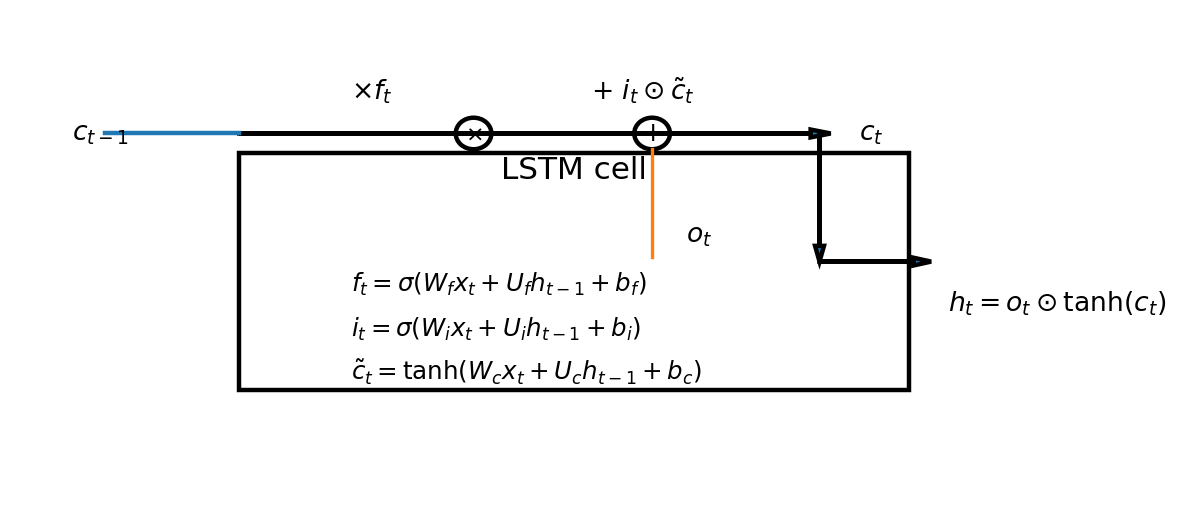

In [1]:
# Diagram: the LSTM cell has an additive cell-state path


## 15. Step-by-step LSTM gradient analysis

The central LSTM advantage appears in the derivative of the cell state.

From

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t,
$$

if we differentiate with respect to $c_{t-1}$ while focusing on the direct memory path, we obtain

$$
\frac{\partial c_t}{\partial c_{t-1}}
=
\operatorname{diag}(f_t).
$$

Therefore, over multiple steps,

$$
\frac{\partial c_t}{\partial c_k}
=
\prod_{i=k+1}^{t} \operatorname{diag}(f_i).
$$

### Why this is better than a simple RNN

In a simple RNN, the Jacobian is roughly $D_i W_h$, which mixes coordinates and includes full matrix multiplication at every step.

In an LSTM memory path, the dominant term is diagonal:

$$
\operatorname{diag}(f_i).
$$

This yields two advantages:

1. no repeated multiplication by a dense recurrent matrix along the cell path,
2. the network can learn $f_i \approx 1$ on dimensions that should retain memory.

If $f_i^{(j)} \approx 1$ for a coordinate $j$, then along that direction

$$
\prod_{i=k+1}^{t} f_i^{(j)} \approx 1,
$$

so the gradient can persist for many steps.

This is the essence of the **constant error carousel** intuition: the architecture creates a near-linear path for memory and gradient transport.


## 16. A small proof of exponential decay in LSTM when forget gates stay below one

Even LSTM can still forget if the forget gate stays too small.

Assume that for one coordinate we have

$$
0 \le f_i^{(j)} \le \rho < 1
\quad \text{for all } i.
$$

Then

$$
\left|
\frac{\partial c_t^{(j)}}{\partial c_k^{(j)}}
\right|
=
\prod_{i=k+1}^{t} f_i^{(j)}
\le
\rho^{\,t-k}.
$$

So the gradient still decays exponentially, but now the model can **learn** whether the factor should be close to $1$ or clearly below it. That learned adaptivity is the major improvement over the fixed dynamics of a simple RNN.


## 17. GRU: Gated Recurrent Unit

The GRU simplifies the LSTM by merging memory and hidden state more tightly.

### 17.1 Standard GRU equations

$$
z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z)
$$

$$
r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r)
$$

$$
\tilde h_t = \tanh\big(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h\big)
$$

$$
h_t = (1-z_t)\odot h_{t-1} + z_t \odot \tilde h_t
$$

Interpretation:

- $z_t$: update gate,
- $r_t$: reset gate,
- $\tilde h_t$: candidate hidden state.

Again, the important feature is an additive interpolation between the old state and a candidate state.


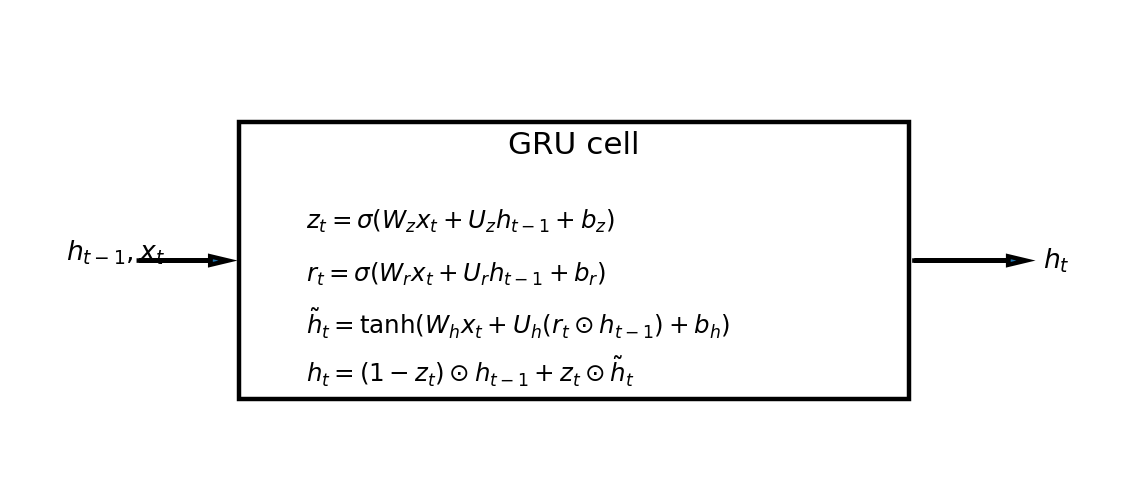

In [1]:
# Diagram: the GRU uses update and reset gates to interpolate memory


## 18. Step-by-step GRU gradient analysis

From

$$
h_t = (1-z_t)\odot h_{t-1} + z_t \odot \tilde h_t,
$$

ignore for a moment the dependence of $z_t$ and $\tilde h_t$ on $h_{t-1}$ and focus only on the explicit skip path. Then

$$
\frac{\partial h_t}{\partial h_{t-1}}
\approx
\operatorname{diag}(1-z_t).
$$

So if a component of $z_t$ is small, the model mostly copies the previous state forward, and the corresponding gradient can also flow backward with little attenuation.

The full Jacobian contains extra terms from the dependence of $z_t$ and $\tilde h_t$ on $h_{t-1}$, but the additive copy path already explains why GRUs are usually much easier to train than simple RNNs.


## 19. Comparing simple RNN, leaky RNN, LSTM, and GRU

### Simple RNN
$$
h_t = \phi(W_h h_{t-1} + W_x x_t + b)
$$

- most compact formulation,
- hardest to train over long horizons,
- gradient dominated by repeated dense Jacobian products.

### Leaky RNN
$$
h_t = \alpha h_{t-1} + (1-\alpha)\tilde h_t
$$

- adds a fixed memory shortcut,
- improves stability,
- still less adaptive than gated models.

### LSTM
$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t
$$

- explicit memory cell,
- strongest control over long-term storage,
- often preferred when long memory is crucial.

### GRU
$$
h_t = (1-z_t)\odot h_{t-1} + z_t \odot \tilde h_t
$$

- simpler than LSTM,
- fewer parameters,
- often competitive in practice.


## 20. PyTorch implementation with annotated mathematics

The following cell implements a simple RNN from scratch.  
The code mirrors the equations exactly:

- affine pre-activation: $a_t = W_h h_{t-1} + W_x x_t + b_h$,
- state update: $h_t = \tanh(a_t)$,
- output: $o_t = W_y h_t + b_y$.


In [ ]:
import torch
import torch.nn as nn

class SimpleRNNCell(nn.Module):
    """
    Implements:
        a_t = W_h h_{t-1} + W_x x_t + b
        h_t = tanh(a_t)
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.W_x = nn.Linear(input_size, hidden_size, bias=False)
        self.W_h = nn.Linear(hidden_size, hidden_size, bias=True)

    def forward(self, x_t, h_prev):
        a_t = self.W_x(x_t) + self.W_h(h_prev)
        h_t = torch.tanh(a_t)
        return h_t

class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = SimpleRNNCell(input_size, hidden_size)
        self.readout = nn.Linear(hidden_size, output_size)

    def forward(self, x, h0=None):
        """
        x shape: (batch, time, input_size)
        """
        batch_size, T, _ = x.shape
        if h0 is None:
            h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        else:
            h = h0

        states = []
        outputs = []
        for t in range(T):
            h = self.cell(x[:, t, :], h)
            y_t = self.readout(h)
            states.append(h)
            outputs.append(y_t)

        H = torch.stack(states, dim=1)   # (batch, time, hidden)
        Y = torch.stack(outputs, dim=1)  # (batch, time, output)
        return Y, H


### Measuring gradient norms in PyTorch

A useful diagnostic for exploding gradients is the global norm:

$$
\|g\|_2 = \sqrt{\sum_i \|g_i\|_2^2}.
$$

The next cell shows a standard training step with clipping.


In [ ]:
def train_step(model, optimizer, criterion, x, target, clip_value=1.0):
    optimizer.zero_grad()

    y_pred, states = model(x)
    loss = criterion(y_pred, target)
    loss.backward()

    # Compute global gradient norm before clipping
    total_sq = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total_sq += p.grad.data.norm(2).item() ** 2
    grad_norm = total_sq ** 0.5

    # Gradient clipping:
    # g <- g * min(1, clip_value / ||g||)
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_value)

    optimizer.step()
    return loss.item(), grad_norm


## 21. A custom LSTM cell in PyTorch

This implementation writes the gates explicitly, which is useful pedagogically.


In [ ]:
class CustomLSTMCell(nn.Module):
    """
    Implements:
        f_t = sigmoid(W_f x_t + U_f h_{t-1} + b_f)
        i_t = sigmoid(W_i x_t + U_i h_{t-1} + b_i)
        g_t = tanh   (W_g x_t + U_g h_{t-1} + b_g)
        o_t = sigmoid(W_o x_t + U_o h_{t-1} + b_o)

        c_t = f_t * c_{t-1} + i_t * g_t
        h_t = o_t * tanh(c_t)
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.x2h = nn.Linear(input_size, 4 * hidden_size, bias=True)
        self.h2h = nn.Linear(hidden_size, 4 * hidden_size, bias=False)

    def forward(self, x_t, state):
        h_prev, c_prev = state
        gates = self.x2h(x_t) + self.h2h(h_prev)
        f_t, i_t, g_t, o_t = gates.chunk(4, dim=-1)

        f_t = torch.sigmoid(f_t)
        i_t = torch.sigmoid(i_t)
        g_t = torch.tanh(g_t)
        o_t = torch.sigmoid(o_t)

        c_t = f_t * c_prev + i_t * g_t
        h_t = o_t * torch.tanh(c_t)
        return h_t, c_t


## 22. JAX implementation with explicit recurrence

JAX makes the recurrence structure very transparent.  
The next cell implements a simple RNN using `jax.lax.scan`, which is the natural way to express:

$$
h_t = \tanh(W_h h_{t-1} + W_x x_t + b).
$$


In [ ]:
import jax
import jax.numpy as jnp
from jax import lax

def init_simple_rnn_params(key, input_size, hidden_size, output_size, scale=0.1):
    k1, k2, k3 = jax.random.split(key, 3)
    params = {
        "W_x": scale * jax.random.normal(k1, (hidden_size, input_size)),
        "W_h": scale * jax.random.normal(k2, (hidden_size, hidden_size)),
        "b_h": jnp.zeros((hidden_size,)),
        "W_y": scale * jax.random.normal(k3, (output_size, hidden_size)),
        "b_y": jnp.zeros((output_size,))
    }
    return params

def simple_rnn_step(params, h_prev, x_t):
    a_t = params["W_x"] @ x_t + params["W_h"] @ h_prev + params["b_h"]
    h_t = jnp.tanh(a_t)
    y_t = params["W_y"] @ h_t + params["b_y"]
    return h_t, (h_t, y_t)

def simple_rnn_forward(params, x_seq, h0):
    """
    x_seq shape: (time, input_size)
    h0 shape: (hidden_size,)
    """
    def scan_fn(h, x_t):
        h_new, outputs = simple_rnn_step(params, h, x_t)
        return h_new, outputs

    hT, (states, outputs) = lax.scan(scan_fn, h0, x_seq)
    return hT, states, outputs


### JAX: differentiating through the full sequence

Because JAX composes transformations cleanly, one can define a sequence loss and differentiate it directly with `jax.grad`.


In [ ]:
def mse_sequence_loss(params, x_seq, targets, h0):
    _, _, outputs = simple_rnn_forward(params, x_seq, h0)
    return jnp.mean((outputs - targets) ** 2)

grad_fn = jax.grad(mse_sequence_loss)


## 23. Practical advice for stable training

1. **Prefer LSTM or GRU** when long-range dependencies matter.
2. **Clip gradients** routinely when using recurrent models.
3. **Initialize recurrent matrices carefully**, often orthogonally.
4. **Monitor gradient norms** during training.
5. **Use layer normalization or residual ideas** when appropriate.
6. **Keep sequence length and truncation horizon explicit** in experiments.
7. **Inspect forget/update gate statistics** in LSTM/GRU models to verify that the network is learning meaningful retention behavior.


## 24. Final summary

The mathematical core of recurrent learning is the product of transition Jacobians:

$$
\frac{\partial h_t}{\partial h_k}
=
\prod_{i=k+1}^{t} \frac{\partial h_i}{\partial h_{i-1}}.
$$

This single expression explains the central optimization pathology of simple RNNs:

- repeated factors below one produce **vanishing gradients**,
- repeated factors above one produce **exploding gradients**.

Leaky units help by injecting a direct memory path.  
LSTMs and GRUs go much further by making memory retention **learned, gated, and additive**.

That is why gated recurrent architectures became the standard solution to long-range gradient instability before Transformer architectures took over many sequence tasks.


# From RNNs to Attention Mechanisms

## Motivation: Limitations of RNNs

Recurrent Neural Networks compress all past information into a single hidden state $h_t$. Even with LSTM/GRU improvements, this creates a **bottleneck**:

- Long-range dependencies are hard to preserve
- Information is mixed into a single vector
- Gradient flow is still indirect across many steps

This motivates a new paradigm: instead of compressing everything into one state, **directly access all past states**.

---

## RNN Perspective

Recall the RNN transformation:

$h_t = \phi(W_h h_{t-1} + W_x x_t + b)$

and output:

$y_t = W_y h_t$

We can interpret this as:

- $W_x$: encodes input into hidden space
- $W_h$: propagates temporal memory
- $W_y$: decodes hidden state into output

---

## Attention: A Generalization

Instead of a single hidden state, attention keeps **all past representations**:

$H = [h_1, h_2, ..., h_T]$

Then computes:

$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d}}\right)V$

---

## Why Three Matrices: $W_Q, W_K, W_V$?

This is not arbitrary — it is a **structured extension of RNN transformations**.

### Analogy with RNN weights:

| RNN | Attention |
|-----|----------|
| $W_x$ | $W_Q, W_K, W_V$ |
| $W_h$ | implicit via attention scores |
| $W_y$ | output projection |


### Interpretation:

- **Query ($Q = XW_Q$)**: "What am I looking for?"
- **Key ($K = XW_K$)**: "What does each token contain?"
- **Value ($V = XW_V$)**: "What information should I retrieve?"

This separation allows the model to:

- Compare representations (Q vs K)
- Retrieve content (V)
- Decouple similarity from information storage

---

## Connection to RNN Computation

In RNNs, influence flows sequentially:

$h_t \leftarrow h_{t-1} \leftarrow h_{t-2} \leftarrow ...$

In attention, influence is **direct**:

$h_t = \sum_{i=1}^{T} \alpha_{t,i} V_i$

where:

$\alpha_{t,i} = \text{softmax}(Q_t K_i^T)$

This removes the need for repeated Jacobian multiplication → no vanishing/exploding through time.

---

## Key Insight

RNN:

- Iterative state update
- Implicit memory via recurrence

Attention:

- Direct memory access
- Explicit weighting of all past states

---

## Conceptual Bridge

You can think of attention as:

> "A soft, learned, content-based generalization of recurrence"

Instead of fixed transitions via $W_h$, we learn **data-dependent connections** via $QK^T$.

---

## Why This Matters

- Eliminates sequential bottleneck
- Enables parallel computation
- Solves long-range dependency issues
- Forms the basis of Transformers


This naturally leads into the next topic: **Transformers and Self-Attention Architectures**.
